In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import datetime

In [2]:
class ProfileHistData:
    def __init__(self,date,xscaleFactor,xscaleFactorError,yscaleFactor,yscaleFactorError,channel):
        #Intiial parameters that I see being useful is the date, and the scaleFactor I can potentially forsee the chi^2 or other such fit parameters being useful. If so implementation should be very simple. 
        self.channels = channel #Specify what channel this scale factor is for (this can be for LSC and NaI)
        self.date = date#Date time format should be used to have accurate plots. 
        self.xscaleFactor = xscaleFactor
        self.xscaleFactorError = xscaleFactorError
        
        self.yscaleFactor = yscaleFactor
        self.yscaleFactorError = yscaleFactorError
        
        self.printLabel = True
        
    def PlotData(self,ax1,ax2,colour,marker, label = False):
        #Plot the data on a scatter plot that you have provided the axis for.
        if label is not False: 
            ax1.scatter(self.date,self.xscaleFactor,color = colour[0],marker = marker[0], label = label)
            ax2.scatter(self.date,self.yscaleFactor,color = colour[1],marker = marker[1], label = label)
        else:
            ax1.scatter(self.date,self.xscaleFactor,color = colour[0],marker = marker[0])
            ax2.scatter(self.date,self.yscaleFactor,color = colour[1],marker = marker[1])
            
        ax1.errorbar(self.date,self.xscaleFactor,yerr = self.xscaleFactorError,color = colour[0],linestyle = None, marker = marker[1])
        ax2.errorbar(self.date,self.yscaleFactor,yerr = self.yscaleFactorError,color = colour[0],linestyle = None, marker = marker[1])

In [3]:
def ReadInProfileData(filepath):
    gammaEnergy = 662
    fitdata = []
    channels = []
    channels.append(str(filepath.stem).split("_")[1])
    channels.append(str(filepath.stem).split("_")[4])
    with open(filepath) as f:
        next(f) #Skips the header of the file. 
        for line in f:
            data = line.split(",")
            time = datetime.datetime(int(data[0].split("_")[0]),int(data[0].split("_")[1]),int(data[0].split("_")[2]))
            channels = [int(data[1]),int(data[2])]
            p0 = float(data[8])
            p0Err = float(data[9])
            p1 = float(data[10])
            p1Err = float(data[11])
            
            xInt = -p0/p1
            yInt = p0
            
            xIntErr = xInt*np.sqrt((p0Err/p0)**2 + (p1Err/p1)**2)
            yIntErr = p0Err
            
            if channels[0] == 4 and channels[1] == 5:
                continue
            else:
                #_(self,date,xscaleFactor,xscaleFactorError,yscaleFactor,yscaleFactorError,channel):
                fitdata.append(ProfileHistData(time,xInt/gammaEnergy,xIntErr/gammaEnergy,yInt/662,yIntErr/662,channels))
            
            
    return fitdata
            
            
            
            

In [4]:
profileHistDateFilepath = Path("/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/2026_04_30/2026_04_30_Daily_LSC_calibration_Cs137_coinc/RAW/Daily_calibration_fits/figures/SDataR_2026_04_30_Daily_LSC_calibration_Cs137_coinc_coinc_4_5_8_fit_results.txt")
fitdata = ReadInProfileData(profileHistDateFilepath)



FileNotFoundError: [Errno 2] No such file or directory: '/home/nick/PhD/KDK+/Daily_LSC_Calibration_testing/2026_04_30/2026_04_30_Daily_LSC_calibration_Cs137_coinc/RAW/Daily_calibration_fits/figures/SDataR_2026_04_30_Daily_LSC_calibration_Cs137_coinc_coinc_4_5_8_fit_results.txt'

NameError: name 'fitdata' is not defined

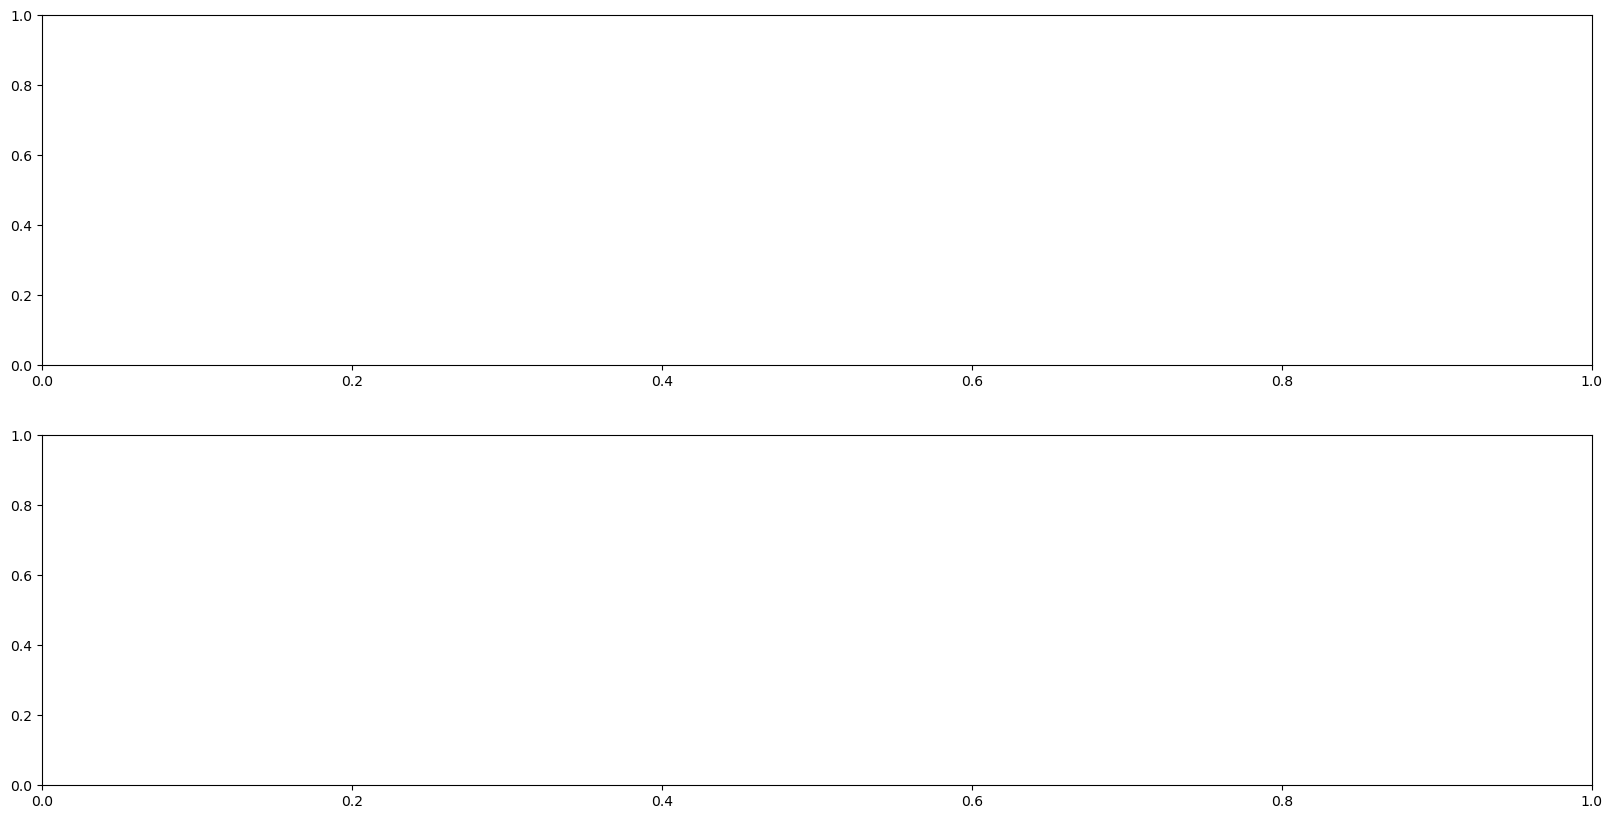

In [ ]:
fig,ax = plt.subplots(2,1,figsize = (20,10))

colourCycle = ['#377eb8', '#ff7f00', '#4daf4a',
              '#f781bf', '#a65628', '#984ea3',
              '#999999', "#e70004", "#8b8b02"]

chcolours = {'ch 4': colourCycle[0],
             'ch 5': colourCycle[1],
             'ch 8': colourCycle[2],
             'ch 10': colourCycle[3],
             'ch 12': colourCycle[4],
             'ch 14': colourCycle[5],
             }


for data in fitdata:
    print(chcolours[f'ch {data.channels[0]}'])
    print(chcolours[f'ch {data.channels[1]}'])
    if data.printLabel:
        label = f'Channel {data.channels[0]} Scale Factor'
        data.printLabel = False
    else: 
        label = False
    data.PlotData(ax[0],ax[1],colour = [chcolours[f'ch {data.channels[0]}'],chcolours[f'ch {data.channels[1]}']], marker = ['^','>'], label = label)
    
ax[0].legend(loc = 'best')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Scale Factor (ADC/keV)')
ax[1].legend(loc = 'best')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Scale Factor (ADC/keV)')

plt.show()